Extraction des données depuis MySQL...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\salma\AppData\Local\Temp\ipykernel_2040\3085902886.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rfm, x='Segment', palette='viridis',


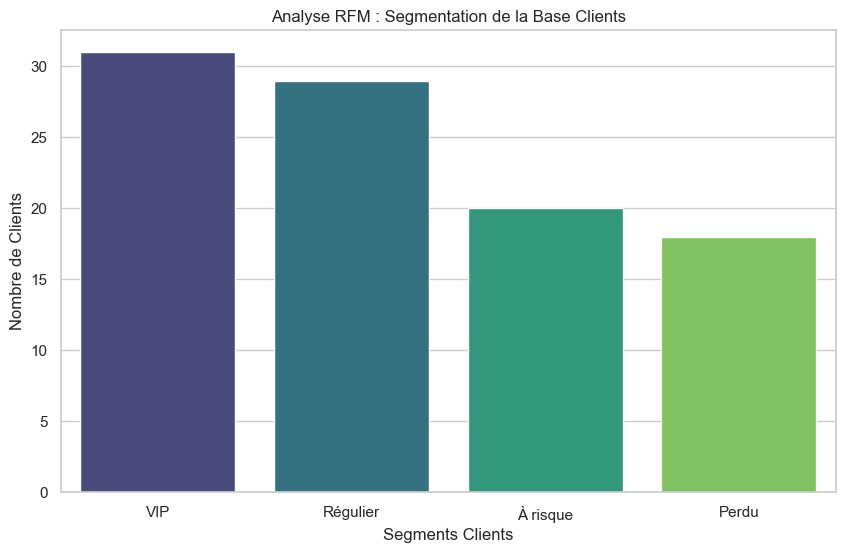

Aperçu de la segmentation :


,customerNumber,recency,frequency,monetary,Segment
0,363,209,34,116449.29,VIP
1,128,208,22,75937.76,À risque
2,181,208,25,72497.64,À risque
3,121,208,32,104224.79,Régulier
4,141,1,259,820689.54,VIP


In [9]:
import sys
import os
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. RÉSOLUTION DU CHEMIN D'IMPORT
# On remonte d'un niveau (de /notebooks vers la racine) pour accéder à /src
sys.path.append(os.path.abspath(os.path.join('..')))

# Importation depuis le chemin spécifique que vous avez précisé
from src.analysis.connection import get_db_data 

# 2. EXTRACTION DES DONNÉES
print("Extraction des données depuis MySQL...")
query = """
    SELECT 
        customerNumber,
        MAX(orderDate) as last_order_date,
        COUNT(orderNumber) as frequency,
        SUM(quantityOrdered * priceEach) as monetary
    FROM orders
    JOIN orderdetails USING (orderNumber)
    GROUP BY customerNumber
"""
df_rfm = get_db_data(query)

# --- CORRECTION DE L'ERREUR DATETIME ---
# On force la conversion pour que l'accesseur .dt fonctionne
df_rfm['last_order_date'] = pd.to_datetime(df_rfm['last_order_date'])
# ---------------------------------------

# 3. CALCUL DE LA RÉCENCE
# Date de référence : lendemain de la dernière commande enregistrée
ref_date = df_rfm['last_order_date'].max() + dt.timedelta(days=1)
df_rfm['recency'] = (ref_date - df_rfm['last_order_date']).dt.days

# 4. SCORING RFM (Quartiles de 1 à 4)
# Récence : plus c'est petit, mieux c'est (score 4)
df_rfm['R'] = pd.qcut(df_rfm['recency'], 4, labels=[4, 3, 2, 1])
# Fréquence et Montant : plus c'est grand, mieux c'est (score 4)
df_rfm['F'] = pd.qcut(df_rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
df_rfm['M'] = pd.qcut(df_rfm['monetary'], 4, labels=[1, 2, 3, 4])

# 5. SEGMENTATION MÉTIER 
def assign_segment(row):
    # On calcule la somme des scores (R+F+M)
    total_score = int(row['R']) + int(row['F']) + int(row['M'])
    
    if total_score >= 10:
        return 'VIP'
    elif total_score >= 7:
        return 'Régulier'
    elif total_score >= 5:
        return 'À risque'
    else:
        return 'Perdu'

df_rfm['Segment'] = df_rfm.apply(assign_segment, axis=1)

# 6. VISUALISATION DES RÉSULTATS
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.countplot(data=df_rfm, x='Segment', palette='viridis', 
              order=['VIP', 'Régulier', 'À risque', 'Perdu'])

plt.title('Analyse RFM : Segmentation de la Base Clients')
plt.xlabel('Segments Clients')
plt.ylabel('Nombre de Clients')
plt.show()

# Affichage des premières lignes pour vérification
print("Aperçu de la segmentation :")
display(df_rfm[['customerNumber', 'recency', 'frequency', 'monetary', 'Segment']].head())